## ELETTRA-48: ID interaction (EU100, U46, F8, EU132, W96, SCW)

In [1]:
# Import

import torch
from torch import Tensor

from pathlib import Path

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
matplotlib.rcParams['text.usetex'] = True

from model.library.element import Element
from model.library.line import Line
from model.library.quadrupole import Quadrupole
from model.library.matrix import Matrix

from model.command.external import load_lattice
from model.command.build import build
from model.command.tune import tune
from model.command.tune import chromaticity
from model.command.orbit import dispersion
from model.command.twiss import twiss
from model.command.advance import advance
from model.command.coupling import coupling

from model.command.wrapper import Wrapper
from model.command.wrapper import forward
from model.command.wrapper import inverse
from model.command.wrapper import normalize

In [2]:
# Set data type and device

Element.dtype = dtype = torch.float64
Element.device = device = torch.device('cpu')

In [3]:
# Load lattice (ELEGANT table)
# Note, lattice is allowed to have repeated elements

path = Path('elettra.lte')
data = load_lattice(path)

In [4]:
# Build and setup lattice

ring:Line = build('RING', 'ELEGANT', data)

# Flatten sublines

ring.flatten()

# Remove all marker elements but the ones starting with MLL (long straight section centers)

ring.remove_group(pattern=r'^(?!MSS_)(?!MLL_).*', kinds=['Marker'])

# Replace all sextupoles with quadrupoles

def factory(element:Element) -> None:
    table = element.serialize
    table.pop('ms', None)
    return Quadrupole(**table)

ring.replace_group(pattern=r'', factory=factory, kinds=['Sextupole'])

# Set linear dipoles

def apply(element:Element) -> None:
    element.linear = True

ring.apply(apply, kinds=['Dipole'])

# Merge drifts

ring.merge()

# Change lattice start

ring.start = "BPM_S01_01"

# Split BPMs

ring.split((None, ['BPM'], None, None))

# Roll lattice

ring.roll(1)

# Splice lattice

ring.splice()

# Describe

ring.describe

{'BPM': 168, 'Drift': 720, 'Dipole': 156, 'Quadrupole': 360, 'Marker': 24}

In [5]:
# Compute tunes (fractional part)

nux, nuy = tune(ring, [], matched=True, limit=1)

In [6]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx, etapx, etaqy, etapy = dispersion(ring, orbit, [], limit=1)

In [7]:
# Compute twiss parameters

ax, bx, ay, by = twiss(ring, [], matched=True, advance=True, full=False).T

In [8]:
# Compute phase advances

mux, muy = advance(ring, [], alignment=False, matched=True).T

In [9]:
# Compute coupling

c = coupling(ring, [])

In [10]:
# Compute chromaticity

psi = chromaticity(ring, [])

In [11]:
# Quadrupole names for global tune correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

In [12]:
# Global tune responce matrix

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(ring, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)

knobs = torch.tensor([0.0, 0.0], dtype=dtype)
global_target = global_observable(knobs)
global_matrix = torch.func.jacfwd(global_observable)(knobs)

print(global_target)
print(global_matrix)

tensor([0.2994, 0.1608], dtype=torch.float64)
tensor([[ 5.8543,  2.0964],
        [-2.9918, -1.2602]], dtype=torch.float64)


In [13]:
# Local knobs

table_nkn = {f'S{i:02}': [f'OCT_S{i:02}_02', f'QF_S{i:02}_02', f'QD_S{i:02}_02', f'QD_S{i:02}_03', f'QF_S{i:02}_03', f'OCT_S{i:02}_03'] for i in range(1, 12 + 1)}
table_nks = {f'S{i:02}': [f'SD_S{i:02}_05', f'SH_S{i:02}_02', f'SH_S{i:02}_03', f'SD_S{i:02}_06'] for i in range(1, 12 + 1)}

In [14]:
# Define twiss observable (full coupled twiss)

def observable_twiss(kn, ks, nkn, nks):
    return twiss(ring, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)

In [15]:
# Define dispersion observable

def observable_dispersion(kn, ks, nkn, nks):  
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(ring, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T

In [16]:
# Construct full target observable vector and corresponding responce matrix (without symmetry)

def observable(knobs, nkn, nks):
    kn, ks = torch.split(knobs, [6, 4])  
    betas = observable_twiss(kn, ks, nkn, nks)
    etas = observable_dispersion(kn, ks, nkn, nks)
    return torch.cat([betas.flatten(), etas.flatten()])

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

sections = [f'S{i:02}' for i in range(1, 12 + 1)]

ts = dict.fromkeys(sections)
ms = dict.fromkeys(sections)

for section in sections:
    ts[section] = observable(knobs, table_nkn[section], table_nks[section])
    ms[section] = torch.func.jacfwd(observable)(knobs, table_nkn[section], table_nks[section])

In [17]:
# Correction container

correction = dict.fromkeys(sections)

In [18]:
# EU100_L01

ARK = torch.tensor([[-6.87458321e-03,  0.00000000e+00,  0.00000000e+00,  4.10330598e-04],
                    [ 0.00000000e+00, -9.32772931e-03,  5.39380718e-04, -1.45557324e-09],
                    [ 0.00000000e+00,  5.39380718e-04,  1.59668799e-02, -3.45623108e-09],
                    [ 4.10330598e-04, -1.45557296e-09, -3.45622909e-09,  2.21701384e-02]], dtype=dtype)

EU100_POS = 0.0
EU100_L01 = Matrix('EU100_L01', length=0.0, A=ARK[torch.triu(torch.ones_like(ARK, dtype=torch.bool))].tolist())

In [19]:
# U46_L02

ARK = torch.tensor([[-0.000116398, 0.0,        0.0,      0.0],
                    [ 0.0,        -0.000219837,0.0,      0.0],
                    [ 0.0,         0.0,        0.0299782,0.0],
                    [ 0.0,         0.0,        0.0,      0.0526229]], dtype=dtype)

U46_POS = 0.0
U46_L02 = Matrix('U46_L02', length=0.0, A=ARK[torch.triu(torch.ones_like(ARK, dtype=torch.bool))].tolist())

In [20]:
# F8_L03

ARK = torch.tensor([[-0.00172735,   0.0,         0.0000718013, 0.0],
                    [ 0.0,         -0.00267732,  0.0,          0.000491118],
                    [ 0.0000718013, 0.0,         0.0225744,    0.0],
                    [ 0.0,          0.000491118, 0.0,          0.0383271]], dtype=dtype)

F8_POS = 0.0
F8_L03 = Matrix('F8_L03', length=0.0, A=ARK[torch.triu(torch.ones_like(ARK, dtype=torch.bool))].tolist())

In [21]:
# EU132_L04

ARK = torch.tensor([[0.0102095,   0.0,        0.0,        -2.47806e-5],
                    [0.0,         0.00542115,  5.1928e-6,   0.0],
                    [0.0,         5.1928e-6,  -0.00352211,  0.0],
                    [-2.47806e-5, 0.0,        0.0,        -0.00199629]], dtype=dtype)

EU132_POS = 928.0
EU132_L04 = Matrix('EU132_L04', length=0.0, A=ARK[torch.triu(torch.ones_like(ARK, dtype=torch.bool))].tolist())

In [22]:
# W96_S05

ARK = torch.tensor([[-0.000248802, 0.0,        0.0,      0.0],
                    [ 0.0,        -9.53447e-6, 0.0,      0.0],
                    [ 0.0,         0.0,        0.0176392,0.0],
                    [ 0.0,         0.0,        0.0,      0.000856368]], dtype=dtype)

W96_POS = 0.0
W96_S05 = Matrix('W96_S05', length=0.0, A=ARK[torch.triu(torch.ones_like(ARK, dtype=torch.bool))].tolist())

In [23]:
# W96_S06

ARK = torch.tensor([[-0.000248802, 0.0,        0.0,      0.0],
                    [ 0.0,        -9.53447e-6, 0.0,      0.0],
                    [ 0.0,         0.0,        0.0176392,0.0],
                    [ 0.0,         0.0,        0.0,      0.000856368]], dtype=dtype)

W96_POS = 0.0
W96_S06 = Matrix('W96_S06', length=0.0, A=ARK[torch.triu(torch.ones_like(ARK, dtype=torch.bool))].tolist())

In [24]:
# SCW_L11

ARK = torch.tensor([[-2.84055e-6, 0.0,        0.0,     0.0],
                    [0.0,         6.85987e-6, 0.0,     0.0],
                    [0.0,         0.0,        0.049742,0.0],
                    [0.0,         0.0,        0.0,     0.0107508]], dtype=dtype)

SCW_POS = 845.8
SCW_L11 = Matrix('SCW_L11', length=0.0, A=ARK[torch.triu(torch.ones_like(ARK, dtype=torch.bool))].tolist())

In [25]:
# S01 (EU100)

section = 'S01'

target = ts[section]
matrix = ms[section]

nkn = table_nkn[section]
nks = table_nks[section]

In [26]:
# Insert ID(s)

error = ring.clone()
error.flatten()
error.insert(EU100_L01, error.next('MLL_S01').name, position=EU100_POS*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 721,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 24,
 'Matrix': 1}

In [27]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [28]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [29]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [30]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [31]:
# Compute coupling

c_id = coupling(error, [])

In [32]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [33]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(0.0052, dtype=torch.float64)
tensor(-0.0032, dtype=torch.float64)


In [34]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)


In [35]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2757, -66.6654], dtype=torch.float64)


In [36]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(error, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)


def observable_twiss(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    return twiss(error, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)


def observable_dispersion(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(error, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T


def observable(knobs):
    kn, ks = torch.split(knobs, [6, 4])
    betas = observable_twiss(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [37]:
# Check the residual vector norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(3.7058e-05, dtype=torch.float64)
tensor(9.2197, dtype=torch.float64)


In [38]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(9.2197, dtype=torch.float64)
tensor(0.5917, dtype=torch.float64)
tensor(0.0483, dtype=torch.float64)
tensor(0.0140, dtype=torch.float64)
tensor(0.0119, dtype=torch.float64)
tensor(0.0117, dtype=torch.float64)
tensor(0.0117, dtype=torch.float64)
tensor(0.0117, dtype=torch.float64)



In [39]:
# Knob values

kn, ks = torch.split(knobs, [6, 4])

print(kn.numpy())
print(ks.numpy())

[-0.01216278  0.00350744  0.0272648   0.05190816 -0.00369919 -0.01582589]
[-0.00014983 -0.0007111   0.0007195   0.00022932]


In [40]:
# Apply final corrections

error.flatten()

for name, knob in zip(nkn, kn):
    error[name].kn = (error[name].kn + knob).item()

for name, knob in zip(nks, ks):
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()

In [41]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(1.1975e-05, dtype=torch.float64)
tensor(0.0117, dtype=torch.float64)


In [42]:
# Compute tunes (fractional part)

nux_id_a, nuy_id_a = tune(error, [], matched=True, limit=1)

In [43]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_a, etapx_id_a, etaqy_id_a, etapy_id_a = dispersion(error, orbit, [], limit=1)

In [44]:
# Compute twiss parameters

ax_id_a, bx_id_a, ay_id_a, by_id_a = twiss(error, [], matched=True, advance=True, full=False).T

In [45]:
# Compute phase advances

mux_id_a, muy_id_a = advance(error, [], alignment=False, matched=True).T

In [46]:
# Compute coupling

c_id_a = coupling(error, [])

In [47]:
# Compute hromaticity

psi_id_a = chromaticity(error, [])

In [48]:
# Tune shifts

print((nux - nux_id_a))
print((nuy - nuy_id_a))

tensor(-0.0006, dtype=torch.float64)
tensor(-0.0034, dtype=torch.float64)


In [49]:
# Coupling (minimal tune distance)

print(c)
print(c_id_a)

tensor(0., dtype=torch.float64)
tensor(1.4725e-06, dtype=torch.float64)


In [50]:
# Chromaticity

print(psi)
print(psi_id_a)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2119, -66.6814], dtype=torch.float64)


In [51]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(1 + 1):
    value = global_observable(global_knobs)
    residual = global_target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(1.1975e-05, dtype=torch.float64)
tensor(7.8273e-07, dtype=torch.float64)



In [52]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.01858255842157612
-0.006756373991750641


In [53]:
# Apply final corrections

error.flatten()

for name in QD:
    error[name].kn = (error[name].kn + kd).item()

for name in QF:
    error[name].kn = (error[name].kn + kf).item()

error.splice()

In [54]:
# Compute tunes (fractional part)

nux_id_b, nuy_id_b = tune(error, [], matched=True, limit=1)

In [55]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_b, etapx_id_b, etaqy_id_b, etapy_id_b = dispersion(error, orbit, [], limit=1)

In [56]:
# Compute twiss parameters

ax_id_b, bx_id_b, ay_id_b, by_id_b = twiss(error, [], matched=True, advance=True, full=False).T

In [57]:
# Compute phase advances

mux_id_b, muy_id_b = advance(error, [], alignment=False, matched=True).T

In [58]:
# Compute coupling

c_id_b = coupling(error, [])

In [59]:
# Compute chromaticity

psi_id_b = chromaticity(error, [])

In [60]:
# Tune shifts

print((nux - nux_id_b))
print((nuy - nuy_id_b))

tensor(-5.3984e-05, dtype=torch.float64)
tensor(-0.0002, dtype=torch.float64)


In [61]:
# Coupling (minimal tune distance)

print(c)
print(c_id_b)

tensor(0., dtype=torch.float64)
tensor(1.5044e-06, dtype=torch.float64)


In [62]:
# Chromaticity

print(psi)
print(psi_id_b)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.1968, -66.6908], dtype=torch.float64)


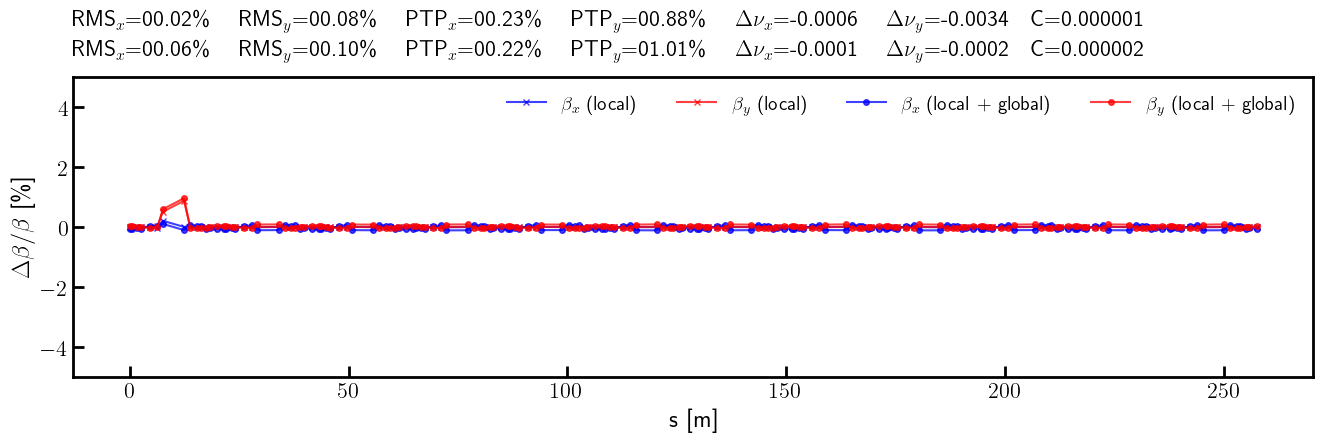

In [63]:
# Beta-beating

bx_a_bb = 100.0*(bx - bx_id_a) / bx
by_a_bb = 100.0*(by - by_id_a) / by

bx_b_bb = 100.0*(bx - bx_id_b) / bx
by_b_bb = 100.0*(by - by_id_b) / by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_a = rms(bx_a_bb).item()
ptp_x_a = (bx_a_bb.max() - bx_a_bb.min()).item()
rms_y_a = rms(by_a_bb).item()
ptp_y_a = (by_a_bb.max() - by_a_bb.min()).item()

rms_x_b = rms(bx_b_bb).item()
ptp_x_b = (bx_b_bb.max() - bx_b_bb.min()).item()
rms_y_b = rms(by_b_bb).item()
ptp_y_b = (by_b_bb.max() - by_b_bb.min()).item()

s = ring.locations().cpu().numpy()

bx_a_np = bx_a_bb.cpu().numpy()
by_a_np = by_a_bb.cpu().numpy()
bx_b_np = bx_b_bb.cpu().numpy()
by_b_np = by_b_bb.cpu().numpy()

fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_a_np, fmt='-', marker='x', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local)')
ax.errorbar(s, by_a_np, fmt='-', marker='x', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local)')
ax.errorbar(s, bx_b_np, fmt='-', marker='o', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global)')
ax.errorbar(s, by_b_np, fmt='-', marker='o', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global)')

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

title = (
    rf'RMS$_x$={rms_x_a:05.2f}\% \quad RMS$_y$={rms_y_a:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_a:05.2f}\% \quad PTP$_y$={ptp_y_a:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_a)}{(nux - nux_id_a).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_a)}{(nuy - nuy_id_a).abs().item():.4f}'
    rf'\quad C={c_id_a.item():.6f}'
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'RMS$_x$={rms_x_b:05.2f}\% \quad RMS$_y$={rms_y_b:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_b:05.2f}\% \quad PTP$_y$={ptp_y_b:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_b)}{(nux - nux_id_b).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_b)}{(nuy - nuy_id_b).abs().item():.4f}'
    rf'\quad C={c_id_b.item():.6f}'
)
ax.text(0.0, 1.05, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-5, 5)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [64]:
# Correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

ring.flatten()
error.flatten()

dkn = {name: (error[name].kn - ring[name].kn).item() for name in nkn}
dks = {name: (error[name].ks - ring[name].ks).item() for name in nks}
dkf = {name: (error[name].kn - ring[name].kn).item() for name in QF}
dkd = {name: (error[name].kn - ring[name].kn).item() for name in QD}

ring.splice()
error.splice()

correction[section] = [dkn, dks, dkf, dkd]

In [65]:
# S02 (U46)

section = 'S02'

target = ts[section]
matrix = ms[section]

nkn = table_nkn[section]
nks = table_nks[section]

In [66]:
# Insert ID(s)

error = ring.clone()
error.flatten()
error.insert(U46_L02, error.next('MLL_S02').name, position=U46_POS*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 721,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 24,
 'Matrix': 1}

In [67]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [68]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [69]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [70]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [71]:
# Compute coupling

c_id = coupling(error, [])

In [72]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [73]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(8.9060e-05, dtype=torch.float64)
tensor(-0.0065, dtype=torch.float64)


In [74]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0., dtype=torch.float64)


In [75]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2098, -66.6617], dtype=torch.float64)


In [76]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(error, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)


def observable_twiss(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    return twiss(error, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)


def observable_dispersion(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(error, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T


def observable(knobs):
    kn, ks = torch.split(knobs, [6, 4])
    betas = observable_twiss(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [77]:
# Check the residual vector norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(4.1768e-05, dtype=torch.float64)
tensor(1.9027, dtype=torch.float64)


In [78]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(1.9027, dtype=torch.float64)
tensor(0.1028, dtype=torch.float64)
tensor(0.0073, dtype=torch.float64)
tensor(0.0022, dtype=torch.float64)
tensor(0.0019, dtype=torch.float64)
tensor(0.0019, dtype=torch.float64)
tensor(0.0019, dtype=torch.float64)
tensor(0.0019, dtype=torch.float64)



In [79]:
# Knob values

kn, ks = torch.split(knobs, [6, 4])

print(kn.numpy())
print(ks.numpy())

[-0.00608958  0.00533462 -0.01241458  0.00040878  0.00160792 -0.00808087]
[-3.11576979e-17 -1.24527230e-17 -4.55368550e-18 -1.49645087e-17]


In [80]:
# Apply final corrections

error.flatten()

for name, knob in zip(nkn, kn):
    error[name].kn = (error[name].kn + knob).item()

for name, knob in zip(nks, ks):
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()

In [81]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(7.1108e-05, dtype=torch.float64)
tensor(0.0019, dtype=torch.float64)


In [82]:
# Compute tunes (fractional part)

nux_id_a, nuy_id_a = tune(error, [], matched=True, limit=1)

In [83]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_a, etapx_id_a, etaqy_id_a, etapy_id_a = dispersion(error, orbit, [], limit=1)

In [84]:
# Compute twiss parameters

ax_id_a, bx_id_a, ay_id_a, by_id_a = twiss(error, [], matched=True, advance=True, full=False).T

In [85]:
# Compute phase advances

mux_id_a, muy_id_a = advance(error, [], alignment=False, matched=True).T

In [86]:
# Compute coupling

c_id_a = coupling(error, [])

In [87]:
# Compute hromaticity

psi_id_a = chromaticity(error, [])

In [88]:
# Tune shifts

print((nux - nux_id_a))
print((nuy - nuy_id_a))

tensor(-1.5048e-05, dtype=torch.float64)
tensor(-0.0084, dtype=torch.float64)


In [89]:
# Coupling (minimal tune distance)

print(c)
print(c_id_a)

tensor(0., dtype=torch.float64)
tensor(1.8091e-18, dtype=torch.float64)


In [90]:
# Chromaticity

print(psi)
print(psi_id_a)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2104, -66.6829], dtype=torch.float64)


In [91]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(1 + 1):
    value = global_observable(global_knobs)
    residual = global_target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(7.1108e-05, dtype=torch.float64)
tensor(4.6876e-06, dtype=torch.float64)



In [92]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.042298359886024206
-0.015160235675036986


In [93]:
# Apply final corrections

error.flatten()

for name in QD:
    error[name].kn = (error[name].kn + kd).item()

for name in QF:
    error[name].kn = (error[name].kn + kf).item()

error.splice()

In [94]:
# Compute tunes (fractional part)

nux_id_b, nuy_id_b = tune(error, [], matched=True, limit=1)

In [95]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_b, etapx_id_b, etaqy_id_b, etapy_id_b = dispersion(error, orbit, [], limit=1)

In [96]:
# Compute twiss parameters

ax_id_b, bx_id_b, ay_id_b, by_id_b = twiss(error, [], matched=True, advance=True, full=False).T

In [97]:
# Compute phase advances

mux_id_b, muy_id_b = advance(error, [], alignment=False, matched=True).T

In [98]:
# Compute coupling

c_id_b = coupling(error, [])

In [99]:
# Compute chromaticity

psi_id_b = chromaticity(error, [])

In [100]:
# Tune shifts

print((nux - nux_id_b))
print((nuy - nuy_id_b))

tensor(-7.4771e-05, dtype=torch.float64)
tensor(-0.0006, dtype=torch.float64)


In [101]:
# Coupling (minimal tune distance)

print(c)
print(c_id_b)

tensor(0., dtype=torch.float64)
tensor(1.8082e-18, dtype=torch.float64)


In [102]:
# Chromaticity

print(psi)
print(psi_id_b)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.1709, -66.6974], dtype=torch.float64)


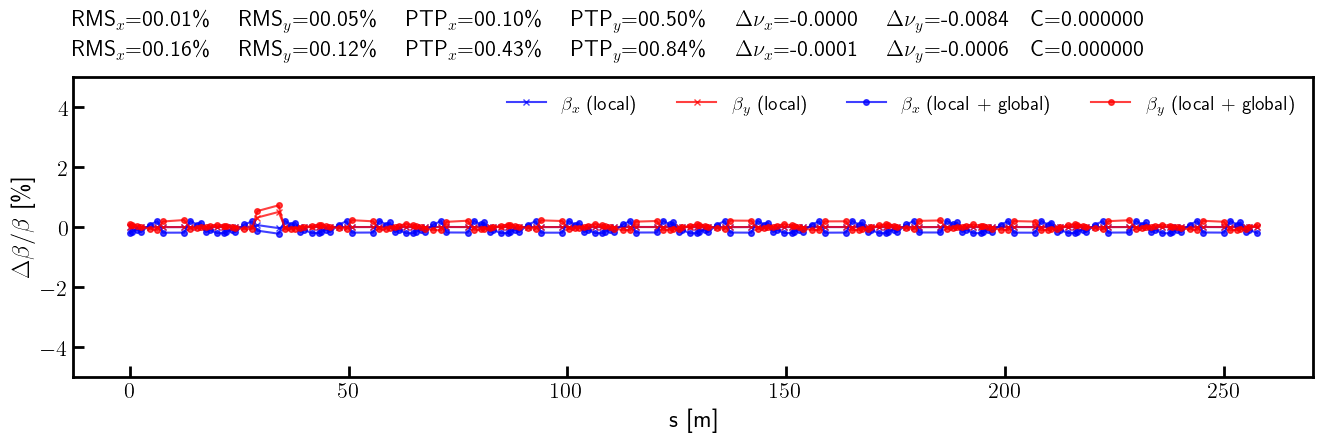

In [103]:
# Beta-beating

bx_a_bb = 100.0*(bx - bx_id_a) / bx
by_a_bb = 100.0*(by - by_id_a) / by

bx_b_bb = 100.0*(bx - bx_id_b) / bx
by_b_bb = 100.0*(by - by_id_b) / by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_a = rms(bx_a_bb).item()
ptp_x_a = (bx_a_bb.max() - bx_a_bb.min()).item()
rms_y_a = rms(by_a_bb).item()
ptp_y_a = (by_a_bb.max() - by_a_bb.min()).item()

rms_x_b = rms(bx_b_bb).item()
ptp_x_b = (bx_b_bb.max() - bx_b_bb.min()).item()
rms_y_b = rms(by_b_bb).item()
ptp_y_b = (by_b_bb.max() - by_b_bb.min()).item()

s = ring.locations().cpu().numpy()

bx_a_np = bx_a_bb.cpu().numpy()
by_a_np = by_a_bb.cpu().numpy()
bx_b_np = bx_b_bb.cpu().numpy()
by_b_np = by_b_bb.cpu().numpy()

fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_a_np, fmt='-', marker='x', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local)')
ax.errorbar(s, by_a_np, fmt='-', marker='x', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local)')
ax.errorbar(s, bx_b_np, fmt='-', marker='o', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global)')
ax.errorbar(s, by_b_np, fmt='-', marker='o', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global)')

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

title = (
    rf'RMS$_x$={rms_x_a:05.2f}\% \quad RMS$_y$={rms_y_a:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_a:05.2f}\% \quad PTP$_y$={ptp_y_a:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_a)}{(nux - nux_id_a).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_a)}{(nuy - nuy_id_a).abs().item():.4f}'
    rf'\quad C={c_id_a.item():.6f}'
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'RMS$_x$={rms_x_b:05.2f}\% \quad RMS$_y$={rms_y_b:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_b:05.2f}\% \quad PTP$_y$={ptp_y_b:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_b)}{(nux - nux_id_b).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_b)}{(nuy - nuy_id_b).abs().item():.4f}'
    rf'\quad C={c_id_b.item():.6f}'
)
ax.text(0.0, 1.05, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-5, 5)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [104]:
# Correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

ring.flatten()
error.flatten()

dkn = {name: (error[name].kn - ring[name].kn).item() for name in nkn}
dks = {name: (error[name].ks - ring[name].ks).item() for name in nks}
dkf = {name: (error[name].kn - ring[name].kn).item() for name in QF}
dkd = {name: (error[name].kn - ring[name].kn).item() for name in QD}

ring.splice()
error.splice()

correction[section] = [dkn, dks, dkf, dkd]

In [105]:
# S03 (F8)

section = 'S03'

target = ts[section]
matrix = ms[section]

nkn = table_nkn[section]
nks = table_nks[section]

In [106]:
# Insert ID(s)

error = ring.clone()
error.flatten()
error.insert(F8_L03, error.next('MLL_S03').name, position=F8_POS*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 721,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 24,
 'Matrix': 1}

In [107]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [108]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [109]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [110]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [111]:
# Compute coupling

c_id = coupling(error, [])

In [112]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [113]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(0.0013, dtype=torch.float64)
tensor(-0.0048, dtype=torch.float64)


In [114]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(6.9883e-05, dtype=torch.float64)


In [115]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2187, -66.6646], dtype=torch.float64)


In [116]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(error, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)


def observable_twiss(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    return twiss(error, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)


def observable_dispersion(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(error, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T


def observable(knobs):
    kn, ks = torch.split(knobs, [6, 4])
    betas = observable_twiss(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [117]:
# Check the residual vector norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(2.4803e-05, dtype=torch.float64)
tensor(1.7504, dtype=torch.float64)


In [118]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(1.7504, dtype=torch.float64)
tensor(0.1079, dtype=torch.float64)
tensor(0.0088, dtype=torch.float64)
tensor(0.0027, dtype=torch.float64)
tensor(0.0024, dtype=torch.float64)
tensor(0.0023, dtype=torch.float64)
tensor(0.0023, dtype=torch.float64)
tensor(0.0023, dtype=torch.float64)



In [119]:
# Knob values

kn, ks = torch.split(knobs, [6, 4])

print(kn.numpy())
print(ks.numpy())

[-0.0067783   0.0042135  -0.00124323  0.01278984  0.00012627 -0.0089216 ]
[-6.08025617e-05  2.68331844e-04  2.65530542e-04 -8.39538522e-05]


In [120]:
# Apply final corrections

error.flatten()

for name, knob in zip(nkn, kn):
    error[name].kn = (error[name].kn + knob).item()

for name, knob in zip(nks, ks):
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()

In [121]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(3.7282e-05, dtype=torch.float64)
tensor(0.0023, dtype=torch.float64)


In [122]:
# Compute tunes (fractional part)

nux_id_a, nuy_id_a = tune(error, [], matched=True, limit=1)

In [123]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_a, etapx_id_a, etaqy_id_a, etapy_id_a = dispersion(error, orbit, [], limit=1)

In [124]:
# Compute twiss parameters

ax_id_a, bx_id_a, ay_id_a, by_id_a = twiss(error, [], matched=True, advance=True, full=False).T

In [125]:
# Compute phase advances

mux_id_a, muy_id_a = advance(error, [], alignment=False, matched=True).T

In [126]:
# Compute coupling

c_id_a = coupling(error, [])

In [127]:
# Compute hromaticity

psi_id_a = chromaticity(error, [])

In [128]:
# Tune shifts

print((nux - nux_id_a))
print((nuy - nuy_id_a))

tensor(-0.0002, dtype=torch.float64)
tensor(-0.0061, dtype=torch.float64)


In [129]:
# Coupling (minimal tune distance)

print(c)
print(c_id_a)

tensor(0., dtype=torch.float64)
tensor(6.5376e-07, dtype=torch.float64)


In [130]:
# Chromaticity

print(psi)
print(psi_id_a)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2106, -66.6820], dtype=torch.float64)


In [131]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(1 + 1):
    value = global_observable(global_knobs)
    residual = global_target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(3.7282e-05, dtype=torch.float64)
tensor(2.4343e-06, dtype=torch.float64)



In [132]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.030918693208962598
-0.011102519274665108


In [133]:
# Apply final corrections

error.flatten()

for name in QD:
    error[name].kn = (error[name].kn + kd).item()

for name in QF:
    error[name].kn = (error[name].kn + kf).item()

error.splice()

In [134]:
# Compute tunes (fractional part)

nux_id_b, nuy_id_b = tune(error, [], matched=True, limit=1)

In [135]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_b, etapx_id_b, etaqy_id_b, etapy_id_b = dispersion(error, orbit, [], limit=1)

In [136]:
# Compute twiss parameters

ax_id_b, bx_id_b, ay_id_b, by_id_b = twiss(error, [], matched=True, advance=True, full=False).T

In [137]:
# Compute phase advances

mux_id_b, muy_id_b = advance(error, [], alignment=False, matched=True).T

In [138]:
# Compute coupling

c_id_b = coupling(error, [])

In [139]:
# Compute chromaticity

psi_id_b = chromaticity(error, [])

In [140]:
# Tune shifts

print((nux - nux_id_b))
print((nuy - nuy_id_b))

tensor(-4.9308e-05, dtype=torch.float64)
tensor(-0.0004, dtype=torch.float64)


In [141]:
# Coupling (minimal tune distance)

print(c)
print(c_id_b)

tensor(0., dtype=torch.float64)
tensor(6.7433e-07, dtype=torch.float64)


In [142]:
# Chromaticity

print(psi)
print(psi_id_b)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.1823, -66.6932], dtype=torch.float64)


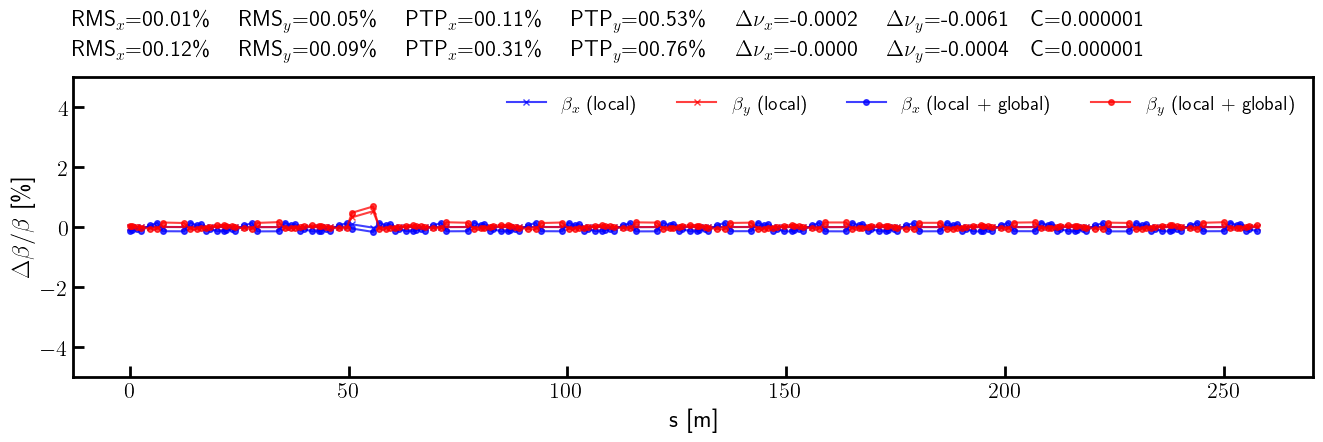

In [143]:
# Beta-beating

bx_a_bb = 100.0*(bx - bx_id_a) / bx
by_a_bb = 100.0*(by - by_id_a) / by

bx_b_bb = 100.0*(bx - bx_id_b) / bx
by_b_bb = 100.0*(by - by_id_b) / by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_a = rms(bx_a_bb).item()
ptp_x_a = (bx_a_bb.max() - bx_a_bb.min()).item()
rms_y_a = rms(by_a_bb).item()
ptp_y_a = (by_a_bb.max() - by_a_bb.min()).item()

rms_x_b = rms(bx_b_bb).item()
ptp_x_b = (bx_b_bb.max() - bx_b_bb.min()).item()
rms_y_b = rms(by_b_bb).item()
ptp_y_b = (by_b_bb.max() - by_b_bb.min()).item()

s = ring.locations().cpu().numpy()

bx_a_np = bx_a_bb.cpu().numpy()
by_a_np = by_a_bb.cpu().numpy()
bx_b_np = bx_b_bb.cpu().numpy()
by_b_np = by_b_bb.cpu().numpy()

fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_a_np, fmt='-', marker='x', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local)')
ax.errorbar(s, by_a_np, fmt='-', marker='x', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local)')
ax.errorbar(s, bx_b_np, fmt='-', marker='o', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global)')
ax.errorbar(s, by_b_np, fmt='-', marker='o', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global)')

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

title = (
    rf'RMS$_x$={rms_x_a:05.2f}\% \quad RMS$_y$={rms_y_a:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_a:05.2f}\% \quad PTP$_y$={ptp_y_a:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_a)}{(nux - nux_id_a).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_a)}{(nuy - nuy_id_a).abs().item():.4f}'
    rf'\quad C={c_id_a.item():.6f}'
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'RMS$_x$={rms_x_b:05.2f}\% \quad RMS$_y$={rms_y_b:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_b:05.2f}\% \quad PTP$_y$={ptp_y_b:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_b)}{(nux - nux_id_b).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_b)}{(nuy - nuy_id_b).abs().item():.4f}'
    rf'\quad C={c_id_b.item():.6f}'
)
ax.text(0.0, 1.05, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-5, 5)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [144]:
# Correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

ring.flatten()
error.flatten()

dkn = {name: (error[name].kn - ring[name].kn).item() for name in nkn}
dks = {name: (error[name].ks - ring[name].ks).item() for name in nks}
dkf = {name: (error[name].kn - ring[name].kn).item() for name in QF}
dkd = {name: (error[name].kn - ring[name].kn).item() for name in QD}

ring.splice()
error.splice()

correction[section] = [dkn, dks, dkf, dkd]

In [145]:
# S04 (EU132)

section = 'S04'

target = ts[section]
matrix = ms[section]

nkn = table_nkn[section]
nks = table_nks[section]

In [146]:
# Insert ID(s)

error = ring.clone()
error.flatten()
error.insert(EU132_L04, error.next('MLL_S04').name, position=EU132_POS*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 721,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 24,
 'Matrix': 1}

In [147]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [148]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [149]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [150]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [151]:
# Compute coupling

c_id = coupling(error, [])

In [152]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [153]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(-0.0078, dtype=torch.float64)
tensor(0.0007, dtype=torch.float64)


In [154]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(1.0048e-05, dtype=torch.float64)


In [155]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2623, -66.6823], dtype=torch.float64)


In [156]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(error, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)


def observable_twiss(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    return twiss(error, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)


def observable_dispersion(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(error, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T


def observable(knobs):
    kn, ks = torch.split(knobs, [6, 4])
    betas = observable_twiss(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [157]:
# Check the residual vector norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(6.1851e-05, dtype=torch.float64)
tensor(19.8483, dtype=torch.float64)


In [158]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(19.8483, dtype=torch.float64)
tensor(1.2198, dtype=torch.float64)
tensor(0.0952, dtype=torch.float64)
tensor(0.0249, dtype=torch.float64)
tensor(0.0205, dtype=torch.float64)
tensor(0.0202, dtype=torch.float64)
tensor(0.0202, dtype=torch.float64)
tensor(0.0202, dtype=torch.float64)



In [159]:
# Knob values

kn, ks = torch.split(knobs, [6, 4])

print(kn.numpy())
print(ks.numpy())

[ 0.00891094  0.00346326 -0.04715884 -0.08306084  0.00258604  0.01972254]
[-3.70389961e-05  2.73780764e-06 -1.13472190e-05  3.55587507e-05]


In [160]:
# Apply final corrections

error.flatten()

for name, knob in zip(nkn, kn):
    error[name].kn = (error[name].kn + knob).item()

for name, knob in zip(nks, ks):
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()

In [161]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(1.7606e-06, dtype=torch.float64)
tensor(0.0202, dtype=torch.float64)


In [162]:
# Compute tunes (fractional part)

nux_id_a, nuy_id_a = tune(error, [], matched=True, limit=1)

In [163]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_a, etapx_id_a, etaqy_id_a, etapy_id_a = dispersion(error, orbit, [], limit=1)

In [164]:
# Compute twiss parameters

ax_id_a, bx_id_a, ay_id_a, by_id_a = twiss(error, [], matched=True, advance=True, full=False).T

In [165]:
# Compute phase advances

mux_id_a, muy_id_a = advance(error, [], alignment=False, matched=True).T

In [166]:
# Compute coupling

c_id_a = coupling(error, [])

In [167]:
# Compute hromaticity

psi_id_a = chromaticity(error, [])

In [168]:
# Tune shifts

print((nux - nux_id_a))
print((nuy - nuy_id_a))

tensor(0.0009, dtype=torch.float64)
tensor(-0.0009, dtype=torch.float64)


In [169]:
# Coupling (minimal tune distance)

print(c)
print(c_id_a)

tensor(0., dtype=torch.float64)
tensor(2.9784e-07, dtype=torch.float64)


In [170]:
# Chromaticity

print(psi)
print(psi_id_a)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2069, -66.6785], dtype=torch.float64)


In [171]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(1 + 1):
    value = global_observable(global_knobs)
    residual = global_target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(1.7606e-06, dtype=torch.float64)
tensor(1.0971e-07, dtype=torch.float64)



In [172]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.0023295305998528772
-0.0006851113772105288


In [173]:
# Apply final corrections

error.flatten()

for name in QD:
    error[name].kn = (error[name].kn + kd).item()

for name in QF:
    error[name].kn = (error[name].kn + kf).item()

error.splice()

In [174]:
# Compute tunes (fractional part)

nux_id_b, nuy_id_b = tune(error, [], matched=True, limit=1)

In [175]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_b, etapx_id_b, etaqy_id_b, etapy_id_b = dispersion(error, orbit, [], limit=1)

In [176]:
# Compute twiss parameters

ax_id_b, bx_id_b, ay_id_b, by_id_b = twiss(error, [], matched=True, advance=True, full=False).T

In [177]:
# Compute phase advances

mux_id_b, muy_id_b = advance(error, [], alignment=False, matched=True).T

In [178]:
# Compute coupling

c_id_b = coupling(error, [])

In [179]:
# Compute chromaticity

psi_id_b = chromaticity(error, [])

In [180]:
# Tune shifts

print((nux - nux_id_b))
print((nuy - nuy_id_b))

tensor(5.8243e-05, dtype=torch.float64)
tensor(-5.8701e-05, dtype=torch.float64)


In [181]:
# Coupling (minimal tune distance)

print(c)
print(c_id_b)

tensor(0., dtype=torch.float64)
tensor(3.0304e-07, dtype=torch.float64)


In [182]:
# Chromaticity

print(psi)
print(psi_id_b)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2012, -66.6745], dtype=torch.float64)


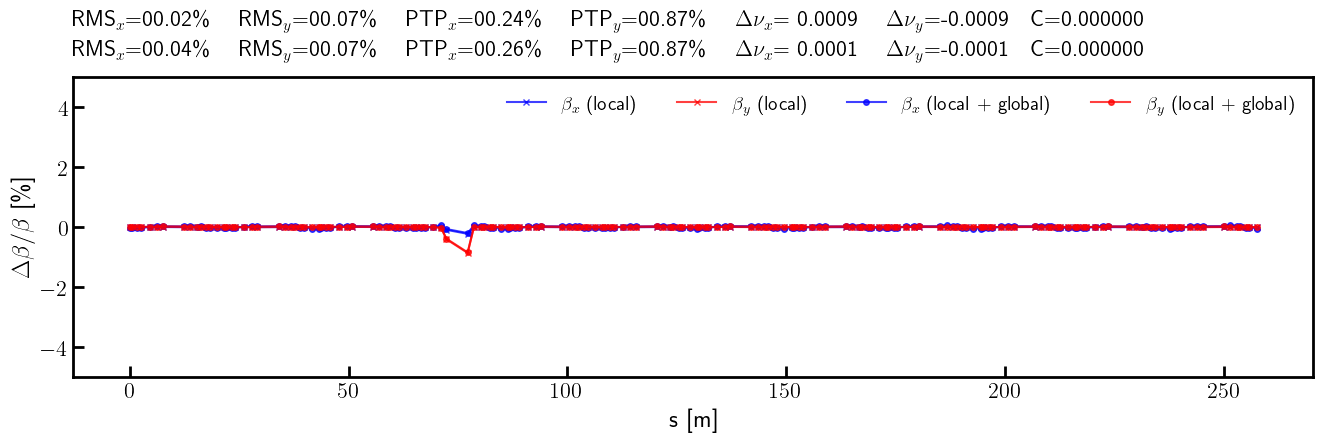

In [183]:
# Beta-beating

bx_a_bb = 100.0*(bx - bx_id_a) / bx
by_a_bb = 100.0*(by - by_id_a) / by

bx_b_bb = 100.0*(bx - bx_id_b) / bx
by_b_bb = 100.0*(by - by_id_b) / by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_a = rms(bx_a_bb).item()
ptp_x_a = (bx_a_bb.max() - bx_a_bb.min()).item()
rms_y_a = rms(by_a_bb).item()
ptp_y_a = (by_a_bb.max() - by_a_bb.min()).item()

rms_x_b = rms(bx_b_bb).item()
ptp_x_b = (bx_b_bb.max() - bx_b_bb.min()).item()
rms_y_b = rms(by_b_bb).item()
ptp_y_b = (by_b_bb.max() - by_b_bb.min()).item()

s = ring.locations().cpu().numpy()

bx_a_np = bx_a_bb.cpu().numpy()
by_a_np = by_a_bb.cpu().numpy()
bx_b_np = bx_b_bb.cpu().numpy()
by_b_np = by_b_bb.cpu().numpy()

fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_a_np, fmt='-', marker='x', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local)')
ax.errorbar(s, by_a_np, fmt='-', marker='x', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local)')
ax.errorbar(s, bx_b_np, fmt='-', marker='o', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global)')
ax.errorbar(s, by_b_np, fmt='-', marker='o', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global)')

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

title = (
    rf'RMS$_x$={rms_x_a:05.2f}\% \quad RMS$_y$={rms_y_a:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_a:05.2f}\% \quad PTP$_y$={ptp_y_a:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_a)}{(nux - nux_id_a).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_a)}{(nuy - nuy_id_a).abs().item():.4f}'
    rf'\quad C={c_id_a.item():.6f}'
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'RMS$_x$={rms_x_b:05.2f}\% \quad RMS$_y$={rms_y_b:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_b:05.2f}\% \quad PTP$_y$={ptp_y_b:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_b)}{(nux - nux_id_b).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_b)}{(nuy - nuy_id_b).abs().item():.4f}'
    rf'\quad C={c_id_b.item():.6f}'
)
ax.text(0.0, 1.05, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-5, 5)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [184]:
# Correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

ring.flatten()
error.flatten()

dkn = {name: (error[name].kn - ring[name].kn).item() for name in nkn}
dks = {name: (error[name].ks - ring[name].ks).item() for name in nks}
dkf = {name: (error[name].kn - ring[name].kn).item() for name in QF}
dkd = {name: (error[name].kn - ring[name].kn).item() for name in QD}

ring.splice()
error.splice()

correction[section] = [dkn, dks, dkf, dkd]

In [185]:
# S11 (SCW)

section = 'S11'

target = ts[section]
matrix = ms[section]

nkn = table_nkn[section]
nks = table_nks[section]

In [186]:
# Insert ID(s)

error = ring.clone()
error.flatten()
error.insert(SCW_L11, error.next('MLL_S11').name, position=SCW_POS*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 721,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 24,
 'Matrix': 1}

In [187]:
# Compute tunes (fractional part)

nux_id, nuy_id = tune(error, [], matched=True, limit=1)

In [188]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id, etapx_id, etaqy_id, etapy_id = dispersion(error, orbit, [], limit=1)

In [189]:
# Compute twiss parameters

ax_id, bx_id, ay_id, by_id = twiss(error, [], matched=True, advance=True, full=False).T

In [190]:
# Compute phase advances

mux_id, muy_id = advance(error, [], alignment=False, matched=True).T

In [191]:
# Compute coupling

c_id = coupling(error, [])

In [192]:
# Compute hromaticity

psi_id = chromaticity(error, [])

In [193]:
# Tune shifts

print((nux - nux_id))
print((nuy - nuy_id))

tensor(2.0874e-06, dtype=torch.float64)
tensor(-0.0086, dtype=torch.float64)


In [194]:
# Coupling (minimal tune distance)

print(c)
print(c_id)

tensor(0., dtype=torch.float64)
tensor(0., dtype=torch.float64)


In [195]:
# Chromaticity

print(psi)
print(psi_id)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2093, -66.7275], dtype=torch.float64)


In [196]:
# Define parametric observable vector

def global_observable(knobs):
    kf, kd = knobs
    kn = torch.stack(len(QF)*[kf] + len(QD)*[kd])
    return tune(error, [kn], ('kn', None, QF + QD, None), matched=True, limit=1)


def observable_twiss(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    return twiss(error, [kn, ks], ('kn', None, nkn, None), ('ks', None, nks, None), matched=True, advance=True, full=False, convert=False)


def observable_dispersion(kn, ks, nkn=table_nkn[section], nks=table_nks[section]):
    orbit = torch.tensor(4*[0.0], dtype=dtype)
    etax, _, etay, _ = dispersion(error, 
                                  orbit,
                                  [kn, ks],
                                  ('kn', None, nkn, None),
                                  ('ks', None, nks, None))
    return torch.stack([etax, etay]).T


def observable(knobs):
    kn, ks = torch.split(knobs, [6, 4])
    betas = observable_twiss(kn, ks)
    etas = observable_dispersion(kn, ks)
    return torch.cat([betas.flatten(), etas.flatten()])

In [197]:
# Check the residual vector norm

global_knobs = torch.tensor(2*[0.0], dtype=dtype)
knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

print(((global_observable(global_knobs) - global_target)**2).sum())
print(((observable(knobs) - target)**2).sum())

tensor(7.4360e-05, dtype=torch.float64)
tensor(48.9830, dtype=torch.float64)


In [198]:
# Optimization loop (local)

# Responce matrix (jacobian)

M = matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

knobs = torch.tensor((6 + 4)*[0.0], dtype=dtype)

# Correction loop

for _ in range(8):
    value = observable(knobs)
    residual = target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    knobs += lr*delta
    print(((value - target)**2).sum())
print()

tensor(48.9830, dtype=torch.float64)
tensor(3.8238, dtype=torch.float64)
tensor(0.4350, dtype=torch.float64)
tensor(0.0999, dtype=torch.float64)
tensor(0.0635, dtype=torch.float64)
tensor(0.0595, dtype=torch.float64)
tensor(0.0590, dtype=torch.float64)
tensor(0.0590, dtype=torch.float64)



In [199]:
# Knob values

kn, ks = torch.split(knobs, [6, 4])

print(kn.numpy())
print(ks.numpy())

[-0.0385348   0.05106073 -0.1382038   0.11085802 -0.03556687 -0.00120526]
[2.06946804e-16 1.24152820e-17 1.14493189e-16 1.19702447e-16]


In [200]:
# Apply final corrections

error.flatten()

for name, knob in zip(nkn, kn):
    error[name].kn = (error[name].kn + knob).item()

for name, knob in zip(nks, ks):
    error[name].ks = (error[name].ks + knob).item()
    
error.splice()

In [201]:
# Check 

print(((global_observable(0.0*global_knobs) - global_target)**2).sum())
print(((observable(0.0*knobs) - target)**2).sum())

tensor(0.0002, dtype=torch.float64)
tensor(0.0590, dtype=torch.float64)


In [202]:
# Compute tunes (fractional part)

nux_id_a, nuy_id_a = tune(error, [], matched=True, limit=1)

In [203]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_a, etapx_id_a, etaqy_id_a, etapy_id_a = dispersion(error, orbit, [], limit=1)

In [204]:
# Compute twiss parameters

ax_id_a, bx_id_a, ay_id_a, by_id_a = twiss(error, [], matched=True, advance=True, full=False).T

In [205]:
# Compute phase advances

mux_id_a, muy_id_a = advance(error, [], alignment=False, matched=True).T

In [206]:
# Compute coupling

c_id_a = coupling(error, [])

In [207]:
# Compute hromaticity

psi_id_a = chromaticity(error, [])

In [208]:
# Tune shifts

print((nux - nux_id_a))
print((nuy - nuy_id_a))

tensor(3.8400e-05, dtype=torch.float64)
tensor(-0.0145, dtype=torch.float64)


In [209]:
# Coupling (minimal tune distance)

print(c)
print(c_id_a)

tensor(0., dtype=torch.float64)
tensor(2.6504e-17, dtype=torch.float64)


In [210]:
# Chromaticity

print(psi)
print(psi_id_a)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.2123, -66.6945], dtype=torch.float64)


In [211]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(1 + 1):
    value = global_observable(global_knobs)
    residual = global_target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(0.0002, dtype=torch.float64)
tensor(1.4458e-05, dtype=torch.float64)



In [212]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.07300308463644578
-0.026168149352525136


In [213]:
# Apply final corrections

error.flatten()

for name in QD:
    error[name].kn = (error[name].kn + kd).item()

for name in QF:
    error[name].kn = (error[name].kn + kf).item()

error.splice()

In [214]:
# Compute tunes (fractional part)

nux_id_b, nuy_id_b = tune(error, [], matched=True, limit=1)

In [215]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_b, etapx_id_b, etaqy_id_b, etapy_id_b = dispersion(error, orbit, [], limit=1)

In [216]:
# Compute twiss parameters

ax_id_b, bx_id_b, ay_id_b, by_id_b = twiss(error, [], matched=True, advance=True, full=False).T

In [217]:
# Compute phase advances

mux_id_b, muy_id_b = advance(error, [], alignment=False, matched=True).T

In [218]:
# Compute coupling

c_id_b = coupling(error, [])

In [219]:
# Compute chromaticity

psi_id_b = chromaticity(error, [])

In [220]:
# Tune shifts

print((nux - nux_id_b))
print((nuy - nuy_id_b))

tensor(-0.0002, dtype=torch.float64)
tensor(-0.0010, dtype=torch.float64)


In [221]:
# Coupling (minimal tune distance)

print(c)
print(c_id_b)

tensor(0., dtype=torch.float64)
tensor(2.6027e-17, dtype=torch.float64)


In [222]:
# Chromaticity

print(psi)
print(psi_id_b)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.1439, -66.7209], dtype=torch.float64)


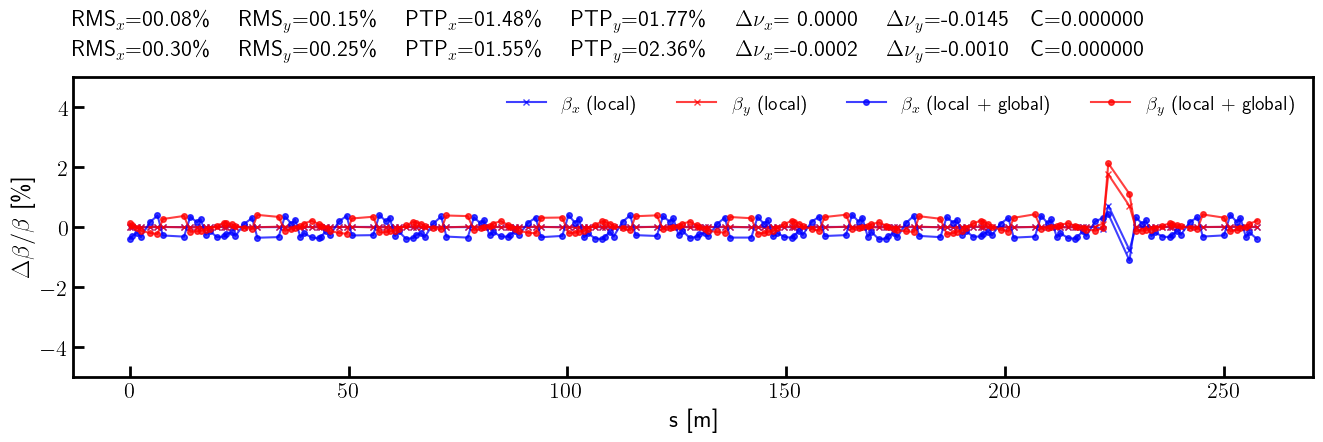

In [223]:
# Beta-beating

bx_a_bb = 100.0*(bx - bx_id_a) / bx
by_a_bb = 100.0*(by - by_id_a) / by

bx_b_bb = 100.0*(bx - bx_id_b) / bx
by_b_bb = 100.0*(by - by_id_b) / by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_a = rms(bx_a_bb).item()
ptp_x_a = (bx_a_bb.max() - bx_a_bb.min()).item()
rms_y_a = rms(by_a_bb).item()
ptp_y_a = (by_a_bb.max() - by_a_bb.min()).item()

rms_x_b = rms(bx_b_bb).item()
ptp_x_b = (bx_b_bb.max() - bx_b_bb.min()).item()
rms_y_b = rms(by_b_bb).item()
ptp_y_b = (by_b_bb.max() - by_b_bb.min()).item()

s = ring.locations().cpu().numpy()

bx_a_np = bx_a_bb.cpu().numpy()
by_a_np = by_a_bb.cpu().numpy()
bx_b_np = bx_b_bb.cpu().numpy()
by_b_np = by_b_bb.cpu().numpy()

fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_a_np, fmt='-', marker='x', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local)')
ax.errorbar(s, by_a_np, fmt='-', marker='x', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local)')
ax.errorbar(s, bx_b_np, fmt='-', marker='o', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global)')
ax.errorbar(s, by_b_np, fmt='-', marker='o', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global)')

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

title = (
    rf'RMS$_x$={rms_x_a:05.2f}\% \quad RMS$_y$={rms_y_a:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_a:05.2f}\% \quad PTP$_y$={ptp_y_a:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_a)}{(nux - nux_id_a).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_a)}{(nuy - nuy_id_a).abs().item():.4f}'
    rf'\quad C={c_id_a.item():.6f}'
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'RMS$_x$={rms_x_b:05.2f}\% \quad RMS$_y$={rms_y_b:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_b:05.2f}\% \quad PTP$_y$={ptp_y_b:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_b)}{(nux - nux_id_b).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_b)}{(nuy - nuy_id_b).abs().item():.4f}'
    rf'\quad C={c_id_b.item():.6f}'
)
ax.text(0.0, 1.05, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-5, 5)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

In [224]:
# Correction

QF = [f'QF_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]
QD = [f'QD_S{i:02}_{j:02}' for j in [2, 3] for i in range(1, 12 + 1)]

ring.flatten()
error.flatten()

dkn = {name: (error[name].kn - ring[name].kn).item() for name in nkn}
dks = {name: (error[name].ks - ring[name].ks).item() for name in nks}
dkf = {name: (error[name].kn - ring[name].kn).item() for name in QF}
dkd = {name: (error[name].kn - ring[name].kn).item() for name in QD}

ring.splice()
error.splice()

correction[section] = [dkn, dks, dkf, dkd]

In [225]:
# Insert ID(s)

error = ring.clone()
error.flatten()

error.insert(EU100_L01, error.next('MLL_S01').name, position=EU100_POS*1.0E-3)
error.insert(U46_L02, error.next('MLL_S02').name, position=U46_POS*1.0E-3)
error.insert(F8_L03, error.next('MLL_S03').name, position=F8_POS*1.0E-3)
error.insert(EU132_L04, error.next('MLL_S04').name, position=EU132_POS*1.0E-3)
error.insert(SCW_L11, error.next('MLL_S11').name, position=SCW_POS*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 725,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 24,
 'Matrix': 5}

In [226]:
# Apply correction

error.flatten()

for section in sections:
    
    if correction[section] is None:
        continue

    nkn = table_nkn[section]
    nks = table_nks[section]

    dkn, dks, dkf, dkd = correction[section]
    
    for name in nkn:
        error[name].kn = error[name].kn.item() + dkn[name]
        
    for name in nks:
        error[name].ks = error[name].ks.item() + dks[name]
    
    for name in QD:
        if name not in nkn:
            error[name].kn = error[name].kn.item() + dkd[name]
    
    for name in QF:
        if name not in nkn:
            error[name].kn = error[name].kn.item() + dkf[name]

error.splice()

In [227]:
# Compute tunes (fractional part)

nux_id_b, nuy_id_b = tune(error, [], matched=True, limit=1)

In [228]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_b, etapx_id_b, etaqy_id_b, etapy_id_b = dispersion(error, orbit, [], limit=1)

In [229]:
# Compute twiss parameters

ax_id_b, bx_id_b, ay_id_b, by_id_b = twiss(error, [], matched=True, advance=True, full=False).T

In [230]:
# Compute phase advances

mux_id_b, muy_id_b = advance(error, [], alignment=False, matched=True).T

In [231]:
# Compute coupling

c_id_b = coupling(error, [])

In [232]:
# Compute chromaticity

psi_id_b = chromaticity(error, [])

In [233]:
# Tune shifts

print((nux - nux_id_b))
print((nuy - nuy_id_b))

tensor(-0.0018, dtype=torch.float64)
tensor(-0.0032, dtype=torch.float64)


In [234]:
# Coupling (minimal tune distance)

print(c)
print(c_id_b)

tensor(0., dtype=torch.float64)
tensor(1.2819e-06, dtype=torch.float64)


In [235]:
# Chromaticity

print(psi)
print(psi_id_b)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.0556, -66.7690], dtype=torch.float64)


In [236]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(1 + 1):
    value = global_observable(global_knobs)
    residual = global_target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(1.3918e-05, dtype=torch.float64)
tensor(2.0316e-06, dtype=torch.float64)



In [237]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.02280581419001947
-0.008521360336182646


In [238]:
# Apply final corrections

error.flatten()

for name in QD:
    error[name].kn = (error[name].kn + kd).item()

for name in QF:
    error[name].kn = (error[name].kn + kf).item()
    
error.splice()

In [239]:
# Compute tunes (fractional part)

nux_id_c, nuy_id_c = tune(error, [], matched=True, limit=1)

In [240]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_c, etapx_id_c, etaqy_id_c, etapy_id_c = dispersion(error, orbit, [], limit=1)

In [241]:
# Compute twiss parameters

ax_id_c, bx_id_c, ay_id_c, by_id_c = twiss(error, [], matched=True, advance=True, full=False).T

In [242]:
# Compute phase advances

mux_id_c, muy_id_c = advance(error, [], alignment=False, matched=True).T

In [243]:
# Compute coupling

c_id_c = coupling(error, [])

In [244]:
# Compute hromaticity

psi_id_c = chromaticity(error, [])

In [245]:
# Tune shifts

print((nux - nux_id_c))
print((nuy - nuy_id_c))

tensor(-0.0004, dtype=torch.float64)
tensor(-0.0004, dtype=torch.float64)


In [246]:
# Coupling (minimal tune distance)

print(c)
print(c_id_c)

tensor(0., dtype=torch.float64)
tensor(1.2891e-06, dtype=torch.float64)


In [247]:
# Chromaticity

print(psi)
print(psi_id_c)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.0408, -66.7922], dtype=torch.float64)


In [248]:
# Chromaticity

(psi_x, psi_y) = psi
(psi_id_b_x, psi_id_b_y) = psi_id_b
(psi_id_c_x, psi_id_c_y) = psi_id_c

print(psi_x, psi_y)
print(psi_id_b_x, psi_id_b_y)
print(psi_id_c_x, psi_id_c_y)

tensor(-71.2093, dtype=torch.float64) tensor(-66.6787, dtype=torch.float64)
tensor(-71.0556, dtype=torch.float64) tensor(-66.7690, dtype=torch.float64)
tensor(-71.0408, dtype=torch.float64) tensor(-66.7922, dtype=torch.float64)


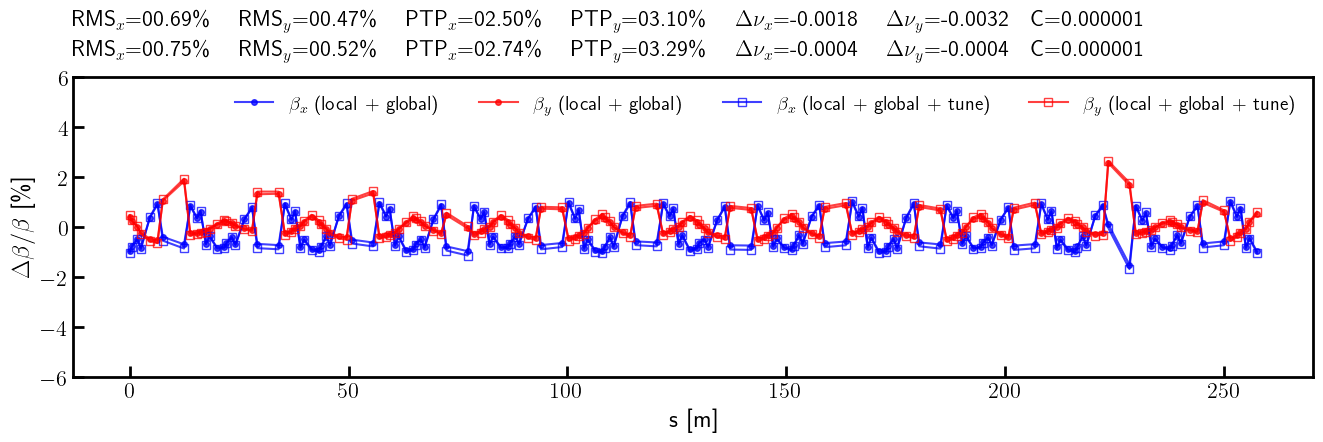

In [249]:
# Beta-beating

bx_b_bb = 100.0*(bx - bx_id_b) / bx
by_b_bb = 100.0*(by - by_id_b) / by

bx_c_bb = 100.0*(bx - bx_id_c) / bx
by_c_bb = 100.0*(by - by_id_c) / by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_b = rms(bx_b_bb).item()
ptp_x_b = (bx_b_bb.max() - bx_b_bb.min()).item()
rms_y_b = rms(by_b_bb).item()
ptp_y_b = (by_b_bb.max() - by_b_bb.min()).item()

rms_x_c = rms(bx_c_bb).item()
ptp_x_c = (bx_c_bb.max() - bx_c_bb.min()).item()
rms_y_c = rms(by_c_bb).item()
ptp_y_c = (by_c_bb.max() - by_c_bb.min()).item()

s = ring.locations().cpu().numpy()

bx_b_np = bx_b_bb.cpu().numpy()
by_b_np = by_b_bb.cpu().numpy()
bx_c_np = bx_c_bb.cpu().numpy()
by_c_np = by_c_bb.cpu().numpy()

fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_b_np, fmt='-', marker='o', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global)')
ax.errorbar(s, by_b_np, fmt='-', marker='o', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global)')
ax.errorbar(s, bx_c_np, fmt='-', marker='s', ms=6, markerfacecolor='none', color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global + tune)')
ax.errorbar(s, by_c_np, fmt='-', marker='s', ms=6, markerfacecolor='none', color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global + tune)')

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')


title = (
    rf'RMS$_x$={rms_x_b:05.2f}\% \quad RMS$_y$={rms_y_b:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_b:05.2f}\% \quad PTP$_y$={ptp_y_b:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_b)}{(nux - nux_id_b).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_b)}{(nuy - nuy_id_b).abs().item():.4f}'
    rf'\quad C={c_id_b.item():.6f}'
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'RMS$_x$={rms_x_c:05.2f}\% \quad RMS$_y$={rms_y_c:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_c:05.2f}\% \quad PTP$_y$={ptp_y_c:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_c)}{(nux - nux_id_c).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_c)}{(nuy - nuy_id_c).abs().item():.4f}'
    rf'\quad C={c_id_c.item():.6f}'
)
ax.text(0.0, 1.05, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-6, 6)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

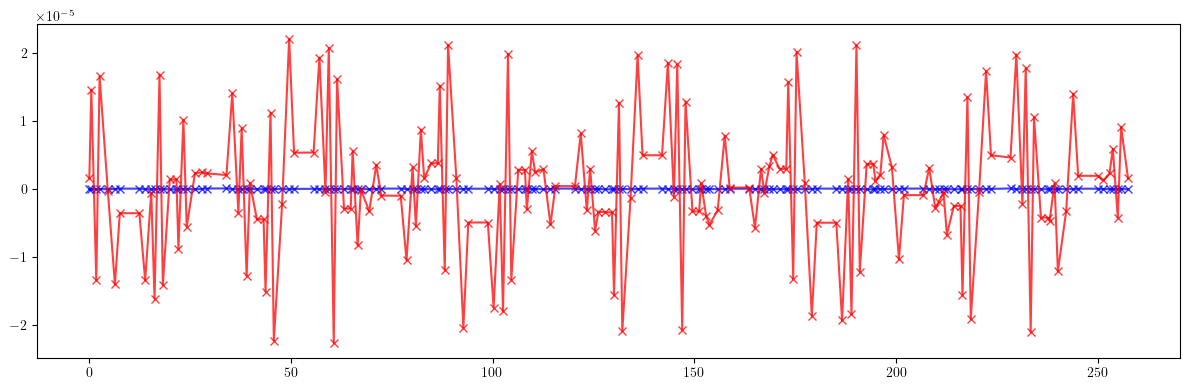

3.098085414602516e-08
1.4623824460407997e-07

1.0108095324680851e-05
4.458100331938437e-05



In [250]:
# Dispersion

plt.figure(figsize=(12, 4))
plt.errorbar(ring.locations().cpu().numpy(), (etaqx - etaqx_id_c).cpu().numpy(), fmt='-', marker='x', color='blue', alpha=0.75)
plt.errorbar(ring.locations().cpu().numpy(), (etaqy - etaqy_id_c).cpu().numpy(), fmt='-', marker='x', color='red', alpha=0.75)

plt.tight_layout()
plt.show()

etax_ref = etaqx - etaqx_id_c
etay_ref = etaqy - etaqy_id_c

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

print(rms_etax_ref)
print(ptp_etax_ref)
print()

print(rms_etay_ref)
print(ptp_etay_ref)
print()

In [251]:
# Insert ID(s)

error = ring.clone()
error.flatten()

error.insert(EU100_L01, error.next('MLL_S01').name, position=EU100_POS*1.0E-3)
error.insert(U46_L02, error.next('MLL_S02').name, position=U46_POS*1.0E-3)
error.insert(F8_L03, error.next('MLL_S03').name, position=F8_POS*1.0E-3)
error.insert(EU132_L04, error.next('MLL_S04').name, position=EU132_POS*1.0E-3)
error.insert(W96_S05, error.next('MSS_S05').name, position=W96_POS*1.0E-3)
error.insert(W96_S06, error.next('MSS_S06').name, position=W96_POS*1.0E-3)
error.insert(SCW_L11, error.next('MLL_S11').name, position=SCW_POS*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 727,
 'Dipole': 156,
 'Quadrupole': 360,
 'Marker': 24,
 'Matrix': 7}

In [252]:
# Apply correction

error.flatten()

for section in sections:
    
    if correction[section] is None:
        continue

    nkn = table_nkn[section]
    nks = table_nks[section]

    dkn, dks, dkf, dkd = correction[section]
    
    for name in nkn:
        error[name].kn = error[name].kn.item() + dkn[name]
        
    for name in nks:
        error[name].ks = error[name].ks.item() + dks[name]
    
    for name in QD:
        if name not in nkn:
            error[name].kn = error[name].kn.item() + dkd[name]
    
    for name in QF:
        if name not in nkn:
            error[name].kn = error[name].kn.item() + dkf[name]

error.splice()

In [253]:
# Compute tunes (fractional part)

nux_id_b, nuy_id_b = tune(error, [], matched=True, limit=1)

In [254]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_b, etapx_id_b, etaqy_id_b, etapy_id_b = dispersion(error, orbit, [], limit=1)

In [255]:
# Compute twiss parameters

ax_id_b, bx_id_b, ay_id_b, by_id_b = twiss(error, [], matched=True, advance=True, full=False).T

In [256]:
# Compute phase advances

mux_id_b, muy_id_b = advance(error, [], alignment=False, matched=True).T

In [257]:
# Compute coupling

c_id_b = coupling(error, [])

In [258]:
# Compute chromaticity

psi_id_b = chromaticity(error, [])

In [259]:
# Tune shifts

print((nux - nux_id_b))
print((nuy - nuy_id_b))

tensor(-0.0017, dtype=torch.float64)
tensor(-0.0089, dtype=torch.float64)


In [260]:
# Coupling (minimal tune distance)

print(c)
print(c_id_b)

tensor(0., dtype=torch.float64)
tensor(1.2180e-06, dtype=torch.float64)


In [261]:
# Chromaticity

print(psi)
print(psi_id_b)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.0514, -66.6208], dtype=torch.float64)


In [262]:
# Optimization loop (global)

# Responce matrix (jacobian)

M = global_matrix.clone()

# Weighting covariance (sensitivity) matrix

epsilon = 1.0E-9
C = M @ M.T
C = C + epsilon*torch.eye(len(C), dtype=dtype)

# Cholesky decomposition

L = torch.linalg.cholesky(C) 

# Whiten response

M = torch.linalg.solve_triangular(L, M, upper=False)

# Additional weights
# Can be used to extra weight selected observables, e.g. tunes

weights = torch.ones(len(M), dtype=dtype)
weights = weights.sqrt()

# Whiten response with additional weights

M = M*weights.unsqueeze(1)

# Iterative correction

lr = 0.75

# Initial value

global_knobs = torch.tensor(2*[0.0], dtype=dtype)

# Correction loop

for _ in range(1 + 1):
    value = global_observable(global_knobs)
    residual = global_target - value
    residual = torch.linalg.solve_triangular(L, residual.unsqueeze(-1), upper=False).squeeze(-1)
    residual = residual*weights
    delta = torch.linalg.lstsq(M, residual, driver="gels").solution
    global_knobs += lr*delta
    print(((value - global_target)**2).sum())
print()

tensor(8.1540e-05, dtype=torch.float64)
tensor(1.0706e-05, dtype=torch.float64)



In [263]:
# Knob values

kf, kd = global_knobs

print(kd.numpy())
print(kf.numpy())

0.05324241824456308
-0.019481179604359446


In [264]:
# Apply final corrections

error.flatten()

for name in QD:
    error[name].kn = (error[name].kn + kd).item()

for name in QF:
    error[name].kn = (error[name].kn + kf).item()
    
error.splice()

In [265]:
# Compute tunes (fractional part)

nux_id_c, nuy_id_c = tune(error, [], matched=True, limit=1)

In [266]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_c, etapx_id_c, etaqy_id_c, etapy_id_c = dispersion(error, orbit, [], limit=1)

In [267]:
# Compute twiss parameters

ax_id_c, bx_id_c, ay_id_c, by_id_c = twiss(error, [], matched=True, advance=True, full=False).T

In [268]:
# Compute phase advances

mux_id_c, muy_id_c = advance(error, [], alignment=False, matched=True).T

In [269]:
# Compute coupling

c_id_c = coupling(error, [])

In [270]:
# Compute hromaticity

psi_id_c = chromaticity(error, [])

In [271]:
# Tune shifts

print((nux - nux_id_c))
print((nuy - nuy_id_c))

tensor(-0.0009, dtype=torch.float64)
tensor(-0.0010, dtype=torch.float64)


In [272]:
# Coupling (minimal tune distance)

print(c)
print(c_id_c)

tensor(0., dtype=torch.float64)
tensor(1.2775e-06, dtype=torch.float64)


In [273]:
# Chromaticity

print(psi)
print(psi_id_c)

tensor([-71.2093, -66.6787], dtype=torch.float64)
tensor([-71.0080, -66.6634], dtype=torch.float64)


In [274]:
# Chromaticity

(psi_x, psi_y) = psi
(psi_id_b_x, psi_id_b_y) = psi_id_b
(psi_id_c_x, psi_id_c_y) = psi_id_c

print(psi_x, psi_y)
print(psi_id_b_x, psi_id_b_y)
print(psi_id_c_x, psi_id_c_y)

tensor(-71.2093, dtype=torch.float64) tensor(-66.6787, dtype=torch.float64)
tensor(-71.0514, dtype=torch.float64) tensor(-66.6208, dtype=torch.float64)
tensor(-71.0080, dtype=torch.float64) tensor(-66.6634, dtype=torch.float64)


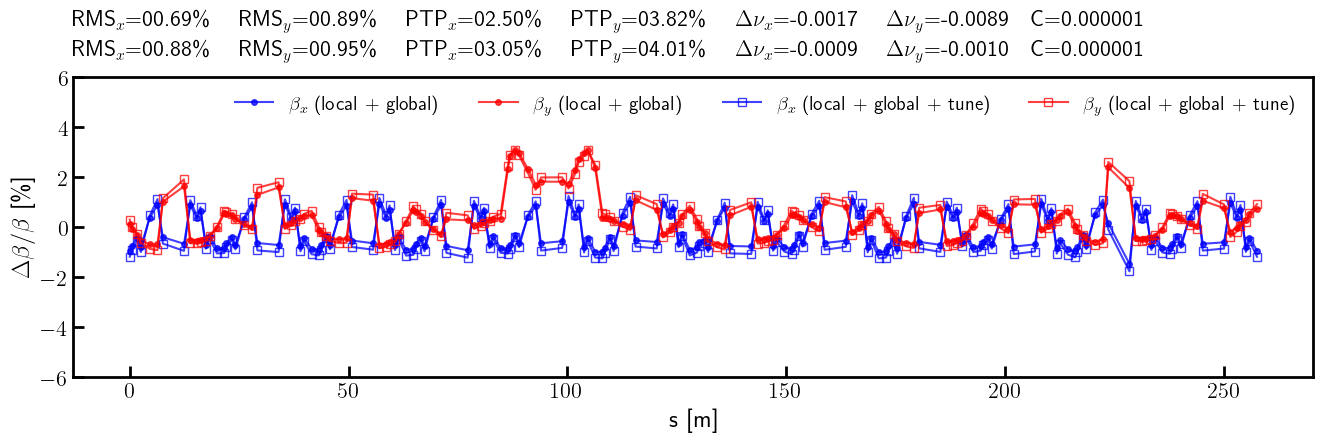

In [275]:
# Beta-beating

bx_b_bb = 100.0*(bx - bx_id_b) / bx
by_b_bb = 100.0*(by - by_id_b) / by

bx_c_bb = 100.0*(bx - bx_id_c) / bx
by_c_bb = 100.0*(by - by_id_c) / by

def rms(x):
    return (x**2).mean().sqrt()

rms_x_b = rms(bx_b_bb).item()
ptp_x_b = (bx_b_bb.max() - bx_b_bb.min()).item()
rms_y_b = rms(by_b_bb).item()
ptp_y_b = (by_b_bb.max() - by_b_bb.min()).item()

rms_x_c = rms(bx_c_bb).item()
ptp_x_c = (bx_c_bb.max() - bx_c_bb.min()).item()
rms_y_c = rms(by_c_bb).item()
ptp_y_c = (by_c_bb.max() - by_c_bb.min()).item()

s = ring.locations().cpu().numpy()

bx_b_np = bx_b_bb.cpu().numpy()
by_b_np = by_b_bb.cpu().numpy()
bx_c_np = bx_c_bb.cpu().numpy()
by_c_np = by_c_bb.cpu().numpy()

fig, ax = plt.subplots(
    1, 1, figsize=(16, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.3}
)

fig.subplots_adjust(top=0.85, bottom=0.35)

ax.errorbar(s, bx_b_np, fmt='-', marker='o', ms=4, color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global)')
ax.errorbar(s, by_b_np, fmt='-', marker='o', ms=4, color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global)')
ax.errorbar(s, bx_c_np, fmt='-', marker='s', ms=6, markerfacecolor='none', color='blue', alpha=0.75, lw=1.5, label=r'$\beta_x$ (local + global + tune)')
ax.errorbar(s, by_c_np, fmt='-', marker='s', ms=6, markerfacecolor='none', color='red',  alpha=0.75, lw=1.5, label=r'$\beta_y$ (local + global + tune)')

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')


title = (
    rf'RMS$_x$={rms_x_b:05.2f}\% \quad RMS$_y$={rms_y_b:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_b:05.2f}\% \quad PTP$_y$={ptp_y_b:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_b)}{(nux - nux_id_b).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_b)}{(nuy - nuy_id_b).abs().item():.4f}'
    rf'\quad C={c_id_b.item():.6f}'
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'RMS$_x$={rms_x_c:05.2f}\% \quad RMS$_y$={rms_y_c:05.2f}\% \quad '
    rf'PTP$_x$={ptp_x_c:05.2f}\% \quad PTP$_y$={ptp_y_c:05.2f}\% \quad '
    rf'$\Delta \nu_x$={(lambda x: '-' if x < 0 else '~')(nux - nux_id_c)}{(nux - nux_id_c).abs().item():.4f} \quad $\Delta \nu_y$={(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_c)}{(nuy - nuy_id_c).abs().item():.4f}'
    rf'\quad C={c_id_c.item():.6f}'
)
ax.text(0.0, 1.05, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-6, 6)

plt.setp(ax.spines.values(), linewidth=2.0)
plt.show()

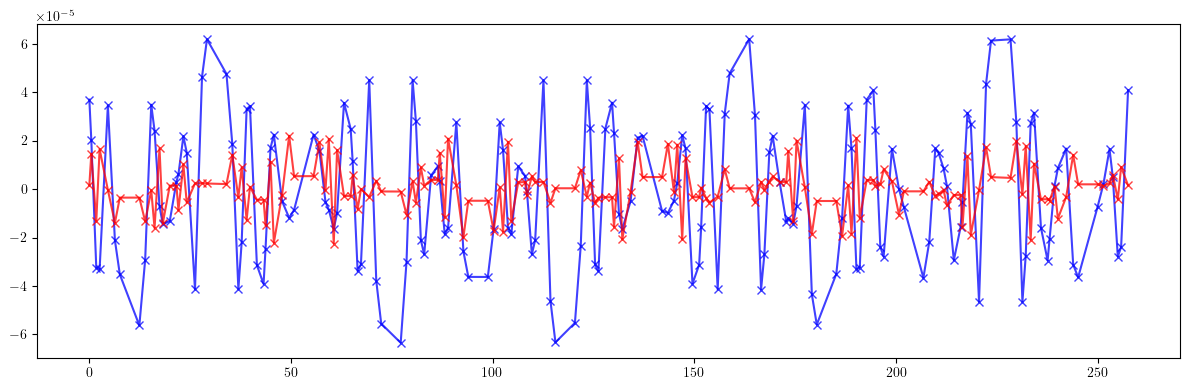

2.963778040361568e-05
0.00012536550004436584

1.0080771427201566e-05
4.4483455191515144e-05



In [276]:
# Dispersion

plt.figure(figsize=(12, 4))
plt.errorbar(ring.locations().cpu().numpy(), (etaqx - etaqx_id_c).cpu().numpy(), fmt='-', marker='x', color='blue', alpha=0.75)
plt.errorbar(ring.locations().cpu().numpy(), (etaqy - etaqy_id_c).cpu().numpy(), fmt='-', marker='x', color='red', alpha=0.75)

plt.tight_layout()
plt.show()

etax_ref = etaqx - etaqx_id_c
etay_ref = etaqy - etaqy_id_c

rms_etax_ref = rms(etax_ref).item()
ptp_etax_ref = (etax_ref.max() - etax_ref.min()).item()
rms_etay_ref = rms(etay_ref).item()
ptp_etay_ref = (etay_ref.max() - etay_ref.min()).item()

print(rms_etax_ref)
print(ptp_etax_ref)
print()

print(rms_etay_ref)
print(ptp_etay_ref)
print()